# Noise-Aware Quantum Circuit Training

One of the biggest misconceptions about quantum computing is that quantum computers are these perfect magical machines that solve impossible problems instantly, when in fact reality is much messier.

Modern quantum hardware is quite noisy.

Every operation:
- introduces small errors
- loses information
- disturbs the quantum state
- pushes computations toward randomness

And unlike classical computers:
> Quantum information is extremely fragile.

This notebook explores one of the most important realities of practical quantum machine learning:
> What actually happens when noise enters the system?

We will:
- train the same variational quantum classifier
- under different noise levels
- compare convergence behavior
- observe prediction degradation
- and connect all of this back to the limitations of modern NISQ hardware

This notebook matters because it moves QML away from fantasy and into reality.

In [1]:
import pennylane as qml
from pennylane import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# What Is Noise?

In quantum computing, noise refers to unintended interactions between a quantum system and its environment.

Quantum states are delicate.

Even tiny disturbances can:
- destroy phase information
- reduce entanglement
- randomize measurements
- corrupt gradients during training

This is one reason building large quantum computers is so difficult, as large and expensive systems must be built to reduce environmental disturbances.

Unlike classical bits:
- Qubits cannot simply be copied for redundancy
- Measurement destroys quantum states
- Errors accumulate rapidly with circuit depth

Modern devices are called:
> NISQ(Noisy Intermediate-Scale Quantum) devices

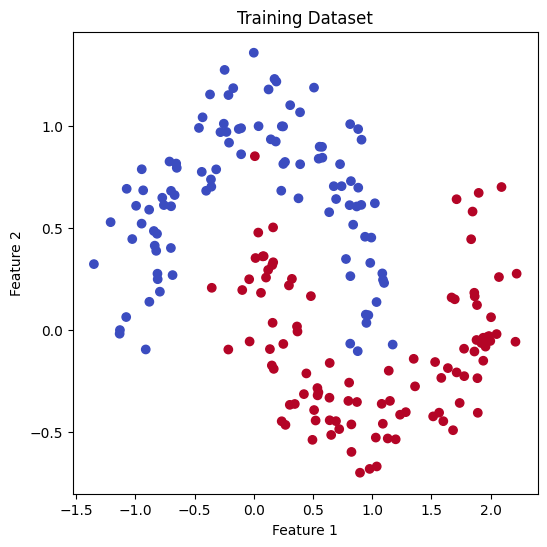

In [2]:
# Create dataset

X, y = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)
y = y * 2 - 1
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm'
)
plt.title("Training Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Depolarizing Noise

One of the most common noise models is called depolarizing noise.

Conceptually, it means:
> With some probability, the qubit partially forgets its state and becomes random.

Mathematically, the state gets pushed toward a maximally mixed state.

You can think of it like progressively smearing information away. Small noise slightly blurs information. Large noise destroys the structure entirely.

This is exactly why the demo on the homepage becomes more random as the noise slider increases.

That visual intuition is actually very accurate.

In [3]:
n_qubits = 2

dev = qml.device("default.mixed", wires=n_qubits)

def noisy_feature_map(x):

    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)


def noisy_ansatz(weights, noise_strength):

    for i in range(n_qubits):

        qml.RY(weights[i], wires=i)

        qml.DepolarizingChannel(
            noise_strength,
            wires=i
        )

    qml.CNOT(wires=[0, 1])
    qml.DepolarizingChannel(
        noise_strength,
        wires=0
    )
    qml.DepolarizingChannel(
        noise_strength,
        wires=1
    )

# Building the Noisy Quantum Circuit

This circuit is almost identical to the clean VQC from the earlier notebook.

The difference is that after the gates execute, we inject depolarizing noise channels, simulating what happens on real hardware.

And importantly:
> Noise accumulates as the circuit becomes deeper.

That accumulation becomes one of the biggest bottlenecks in modern QML.

In [4]:
@qml.qnode(dev)
def noisy_circuit(x, weights, noise_strength):

    noisy_feature_map(x)

    noisy_ansatz(weights, noise_strength)

    return qml.expval(qml.PauliZ(0))

In [5]:
def mse_loss(y_true, y_pred):

    return np.mean((y_true - y_pred) ** 2)


def cost(weights, X, y, noise_strength):

    preds = np.array([
        noisy_circuit(x, weights, noise_strength)
        for x in X
    ])

    return mse_loss(y, preds)


def predict(X, weights, noise_strength):

    preds = np.array([
        noisy_circuit(x, weights, noise_strength)
        for x in X
    ])

    return np.sign(preds)

# Training Under Different Noise Levels

We will now train the exact same model under:
- no noise
- moderate noise
- heavy noise

This is important scientifically.

Because if a model only works in perfect simulation:
> it may not be useful on actual hardware.

In [6]:
noise_levels = {
    "No Noise": 0.0,
    "Moderate Noise": 0.03,
    "High Noise": 0.12
}

results = {}
epochs = 60

for label, noise_strength in noise_levels.items():

    weights = np.random.randn(n_qubits, requires_grad=True)

    optimizer = qml.GradientDescentOptimizer(
        stepsize=0.1
    )

    loss_history = []
    for epoch in range(epochs):
        weights = optimizer.step(
            lambda w: cost(
                w,
                X_train,
                y_train,
                noise_strength
            ),
            weights
        )

        current_loss = cost(
            weights,
            X_train,
            y_train,
            noise_strength
        )

        loss_history.append(current_loss)

    preds = predict(
        X_test,
        weights,
        noise_strength
    )

    acc = accuracy_score(y_test, preds)

    results[label] = {
        "weights": weights,
        "loss_history": loss_history,
        "accuracy": acc,
        "noise_strength": noise_strength
    }

# Visualizing Training Stability

This graph is one of the most important visualizations in the notebook.

Watch what happens as noise increases:
- convergence becomes less stable
- optimization slows down
- loss fluctuates more aggressively
- gradients become less informative

Eventually:
> The circuit starts learning randomness instead of structure.

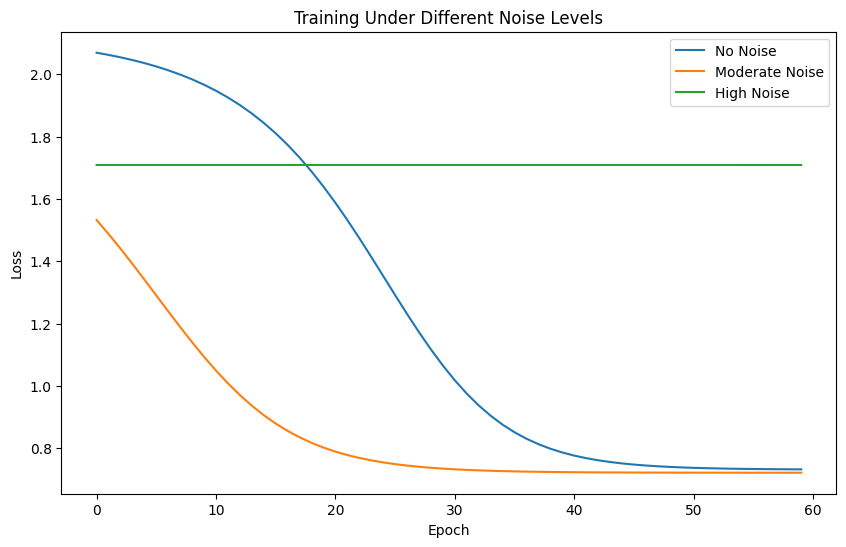

In [7]:
plt.figure(figsize=(10, 6))

for label, data in results.items():

    plt.plot(
        data["loss_history"],
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Under Different Noise Levels")

plt.legend()

plt.show()

# Accuracy Degradation

Now we measure final classification accuracy, which is where the practical cost of noise becomes obvious.

Even if the model architecture remains identical:
- performance drops
- predictions become unstable
- learned boundaries deteriorate

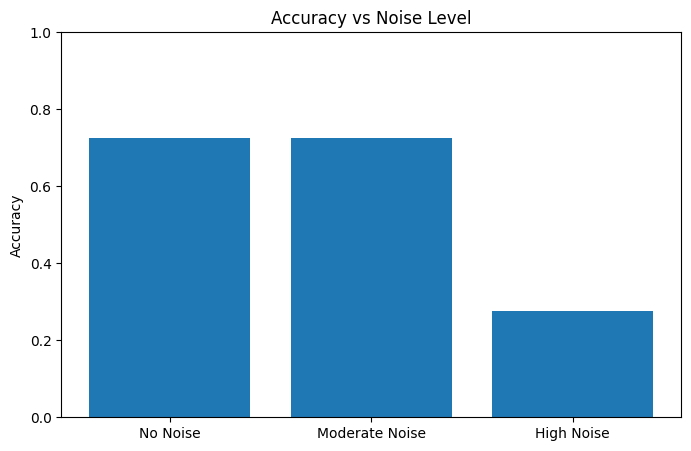

In [8]:
labels = list(results.keys())

accuracies = [
    results[label]["accuracy"]
    for label in labels
]

plt.figure(figsize=(8, 5))

plt.bar(labels, accuracies)

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.title("Accuracy vs Noise Level")

plt.show()

# Visualizing Prediction Regions

This visualization is probably the clearest demonstration of noise effects.

As noise increases:
- decision boundaries become less confident
- structure becomes blurrier
- predictions become unstable

Eventually, the model begins behaving almost randomly.

In [9]:
xx, yy = np.meshgrid(
    np.linspace(-2, 3, 150),
    np.linspace(-1.5, 2, 150)
)

grid = np.c_[xx.ravel(), yy.ravel()]

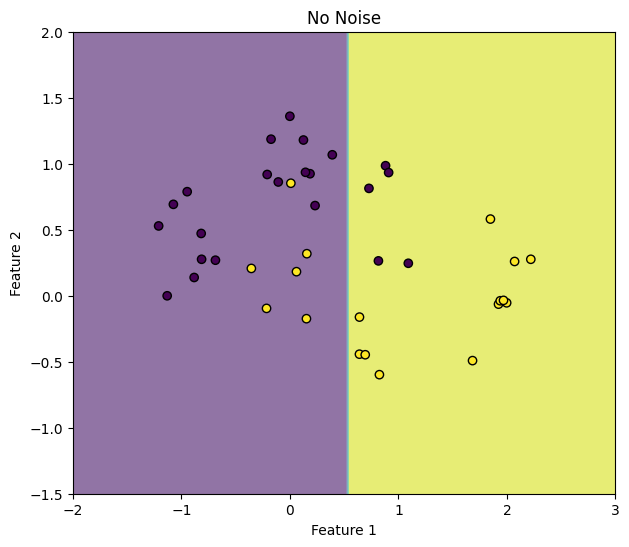

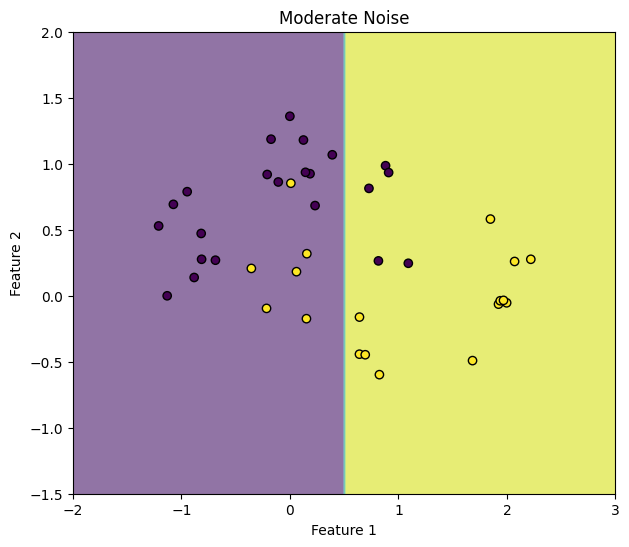

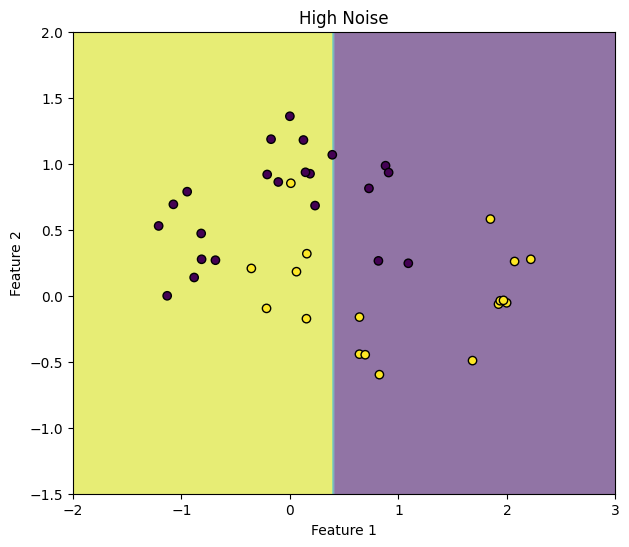

In [10]:
for label, data in results.items():

    preds = np.array([
        noisy_circuit(
            point,
            data["weights"],
            data["noise_strength"]
        )
        for point in grid
    ])

    Z = np.sign(preds).reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.6
    )

    plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        edgecolors='black'
    )

    plt.title(label)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()

# A Closer Look At Boundaries

The low-noise circuit learns meaningful geometric structure, but as noise increases:
- boundaries become distorted
- regions fragment unpredictably
- confidence collapses

This directly mirrors the homepage demo.

# Why Noise Breaks Training

Variational quantum circuits rely heavily on:
- Interference
- Phase relationships
- Precise amplitudes
- Coherent transformations

And noise destroys those properties.

And because gradients already tend to become small in larger circuits, noise can completely overwhelm the optimization signal.

This creates one of the defining bottlenecks of NISQ-era QML:
- Expressive circuits are harder to train
- Deeper circuits accumulate more noise
- Hardware errors limit scalability

# NISQ Limitations

This notebook demonstrates a major reality of modern quantum computing: We are not yet in the era of large fault-tolerant quantum systems.

Current devices:
- have limited qubit counts
- have finite coherence times
- suffer gate errors
- suffer readout errors
- accumulate noise rapidly

This means:
> Shallow circuits are currently favored over deep ones.

And this shapes almost the entire design philosophy of modern QML research.

# Is QML Redundant/Doomed?

Not necessarily, but it does mean:
- Practical quantum advantage is harder than many early papers suggested
- Hardware-aware algorithm design matters
- Error mitigation becomes important
- Benchmarking against classical methods is essential

Modern QML research is increasingly becoming:
- more realistic
- more skeptical
- more engineering-focused

# Final Reflection

This notebook connected several major ideas:
- variational circuits
- optimization
- geometric learning
- hardware noise
- NISQ constraints
- trainability degradation

A lot of popular discussions about quantum computing focus entirely on theoretical power.

What actually matters in practice is:
- stability
- scalability
- robustness
- and whether useful signals survive physical reality.

That tension between:
- elegant mathematical theory
and
- messy physical hardware

is one of the defining characteristics of quantum machine learning today.